# `generate_candidates` — pass-2 representative strategies

Pass 2 of `generate_candidates` places **one representative candidate** inside each
connected navigable region that the pass-1 grid missed (e.g. a room or aisle smaller
than the grid step). This notebook compares two ways of choosing that representative.

| Strategy | Rule | Property |
|----------|------|----------|
| **CURRENT** | `mid = len(np.where(labeled==id))//2` — the median pixel in **row-major scan order** | Not a geometric centre; on concave shapes (L / ring) it can land off-centre or near an edge. Also does one full `H×W` scan **per component**. |
| **NEW (deepest-inside)** | pixel with **max distance-to-wall** in the component (`distance_transform_edt` argmax), found via a single grouped pass | Wall-safe by construction: always as far from obstacles as the region allows. Consistent with pass 3, which already uses the distance transform. |

The unit tests (`TestGenerateCandidates`) only assert **count** and **navigability** of the
representatives — never an exact pixel — so any centre that stays inside the region and
yields the same number of reps passes. This notebook is the visual justification for the
switch.

> Note: `generate_candidates` runs on the **inflated** `navigable_mask`, so every candidate
> is already `>= inflation_radius` from a real wall. The `inflate()` helper below reproduces
> `build_map_data`'s formula exactly.

In [1]:
import sys
from pathlib import Path

import numpy as np
import yaml
from PIL import Image
from scipy.ndimage import label as ndlabel, distance_transform_edt
import matplotlib.pyplot as plt

# Repo root: notebook lives at .../exploration/tests/algo_comparison/
ROOT = Path.cwd()
while not (ROOT / ".git").exists() and not (ROOT / "docker-compose.yml").is_file():
    ROOT = ROOT.parent
ASSETS = ROOT / "assets"
sys.path.insert(0, str(ROOT / "ros2_ws/src/navigation/exploration"))
from exploration.explore_costmap_map import build_map_data  # noqa: E402

MIN_COMPONENT_CELLS = 100  # matches generate_candidates


def inflate(free, px):
    """Reproduce build_map_data inflation: navigable = free & (dist-to-obstacle > px).
    occupied = ~free, so distance_transform_edt(~occupied) == distance_transform_edt(free)."""
    occupied = ~free
    return free & (distance_transform_edt(~occupied) > px)


def grid_pass(navigable, step):
    """Pass 1 (identical in both strategies) — used only to decide which regions pass 2 must fill."""
    H, W = navigable.shape
    return {(c, r) for r in range(0, H, step) for c in range(0, W, step) if navigable[r, c]}


print("repo root:", ROOT)

repo root: /home/idlab332/workspace/ros_ws/src/TRAVIS


## The two pass-2 strategies

Both take the inflated `navigable_mask` and the pass-1 `grid`, and return the list of
representative `(col, row)` points pass 2 would add. Only the **selection rule** differs;
the size threshold and grid-coverage skip are identical.

In [2]:
def pass2_current(navigable, grid):
    """CURRENT: row-major median pixel. Exact copy of the shipped logic."""
    labeled, n = ndlabel(navigable)
    comp_size = {cid: int(np.sum(labeled == cid)) for cid in range(1, n + 1)}
    reps = []
    for cid in range(1, n + 1):
        rows_nav, cols_nav = np.where(labeled == cid)
        if comp_size[cid] < MIN_COMPONENT_CELLS:
            continue
        if any(labeled[row, col] == cid for col, row in grid):
            continue
        mid = len(rows_nav) // 2
        reps.append((int(cols_nav[mid]), int(rows_nav[mid])))
    return reps


def pass2_new(navigable, grid):
    """NEW: deepest-inside pixel (max distance-to-wall) via ONE grouped pass.
    Sizes come from np.bincount (single pass instead of one np.sum per component)."""
    labeled, n = ndlabel(navigable)
    counts = np.bincount(labeled.ravel())               # counts[label] = size; index 0 = background
    dist = distance_transform_edt(navigable)            # distance-to-wall for every navigable cell
    # group foreground pixels by label in row-major order, one pass
    rows_all, cols_all = np.where(labeled > 0)
    labs = labeled[rows_all, cols_all]
    order = np.argsort(labs, kind="stable")
    rs, cs, ls = rows_all[order], cols_all[order], labs[order]
    starts = np.searchsorted(ls, np.arange(1, n + 1), "left")
    ends = np.searchsorted(ls, np.arange(1, n + 1), "right")
    reps = []
    for i, cid in enumerate(range(1, n + 1)):
        if counts[cid] < MIN_COMPONENT_CELLS:
            continue
        if any(labeled[row, col] == cid for col, row in grid):
            continue
        s, e = starts[i], ends[i]
        rr, cc = rs[s:e], cs[s:e]
        k = int(np.argmax(dist[rr, cc]))                # deepest-inside pixel
        reps.append((int(cc[k]), int(rr[k])))
    return reps

## Test cases

- **Real maps** (`lab_ghent`, `lab_05`) — production geometry, inflated at 0.9 m like the tests.
- **L-shape** — concave; centroid-based picks would hug the inner corner.
- **Ring / donut** — worst concave case: the geometric centre is a non-navigable hole.
- **Thin diagonal** — long narrow band.
- **Multi-region** — three separate rooms; checks the grouped pass indexes each region correctly.

Synthetic masks use the `inflate()` helper so they mirror what production feeds the planner.

In [3]:
def load_real(map_dir):
    yml = yaml.safe_load(open(map_dir / "map.yaml"))
    arr = np.array(Image.open(map_dir / "map.pgm"), dtype=np.uint8)
    res = float(yml["resolution"])
    p_occ = 1.0 - arr.astype(np.float64) / 255.0
    md = build_map_data(p_occ, res, 0.0, 0.0, inflation_radius_m=0.9)
    step = max(1, int(3.0 / res))  # sampling_step_m = 3.0 default
    return md.navigable_mask, step


def make_L():
    free = np.zeros((160, 160), bool)
    free[20:60, 20:140] = True   # top arm
    free[20:140, 20:60] = True   # left leg -> L
    return inflate(free, 1.0)


def make_ring():
    free = np.zeros((160, 160), bool)
    free[20:140, 20:140] = True
    free[55:105, 55:105] = False  # hole -> donut; centroid lands in the hole
    return inflate(free, 1.0)


def make_diag():
    base = np.zeros((160, 160), bool)
    for i in range(130):
        r, c = 15 + i, 15 + i
        base[max(0, r - 5):r + 6, max(0, c - 5):c + 6] = True
    return inflate(base, 1.0)


def make_multi():
    free = np.zeros((240, 240), bool)
    free[10:50, 10:50] = True      # room A
    free[10:50, 190:230] = True    # room B
    free[190:230, 100:140] = True  # room C
    return inflate(free, 1.0)


CASES = [
    ("lab_ghent", *load_real(ASSETS / "lab_ghent")),
    ("lab_05", *load_real(ASSETS / "lab_05")),
    ("L-shape", make_L(), 200),
    ("ring/donut", make_ring(), 200),
    ("thin diagonal", make_diag(), 200),
    ("multi-region (3 rooms)", make_multi(), 70),
]
print(f"{len(CASES)} cases loaded")

6 cases loaded


## Side-by-side comparison

Left = CURRENT (row-major median), right = NEW (deepest-inside). Red ★ = pass-2 representative.
The title reports each rep's **distance-to-wall in pixels** (bigger = safer).

case                      #cur  #new   current -> new  (min d_wall px)
lab_ghent                    1     1   [(391, 132)] -> [(427, 132)]   (cur 2.0 / new 3.2)  nav ok: cur=True new=True
lab_05                       1     1   [(202, 146)] -> [(45, 146)]   (cur 13.0 / new 20.0)  nav ok: cur=True new=True
L-shape                      1     1   [(125, 52)] -> [(43, 43)]   (cur 7.0 / new 23.0)  nav ok: cur=True new=True
ring/donut                   1     1   [(21, 80)] -> [(40, 40)]   (cur 1.0 / new 20.0)  nav ok: cur=True new=True
thin diagonal                1     1   [(71, 80)] -> [(18, 18)]   (cur 1.0 / new 7.1)  nav ok: cur=True new=True
multi-region (3 rooms)       3     3   [(11, 30), (191, 30), (101, 210)] -> [(29, 29), (209, 29), (119, 209)]   (cur 1.0 / new 19.0)  nav ok: cur=True new=True


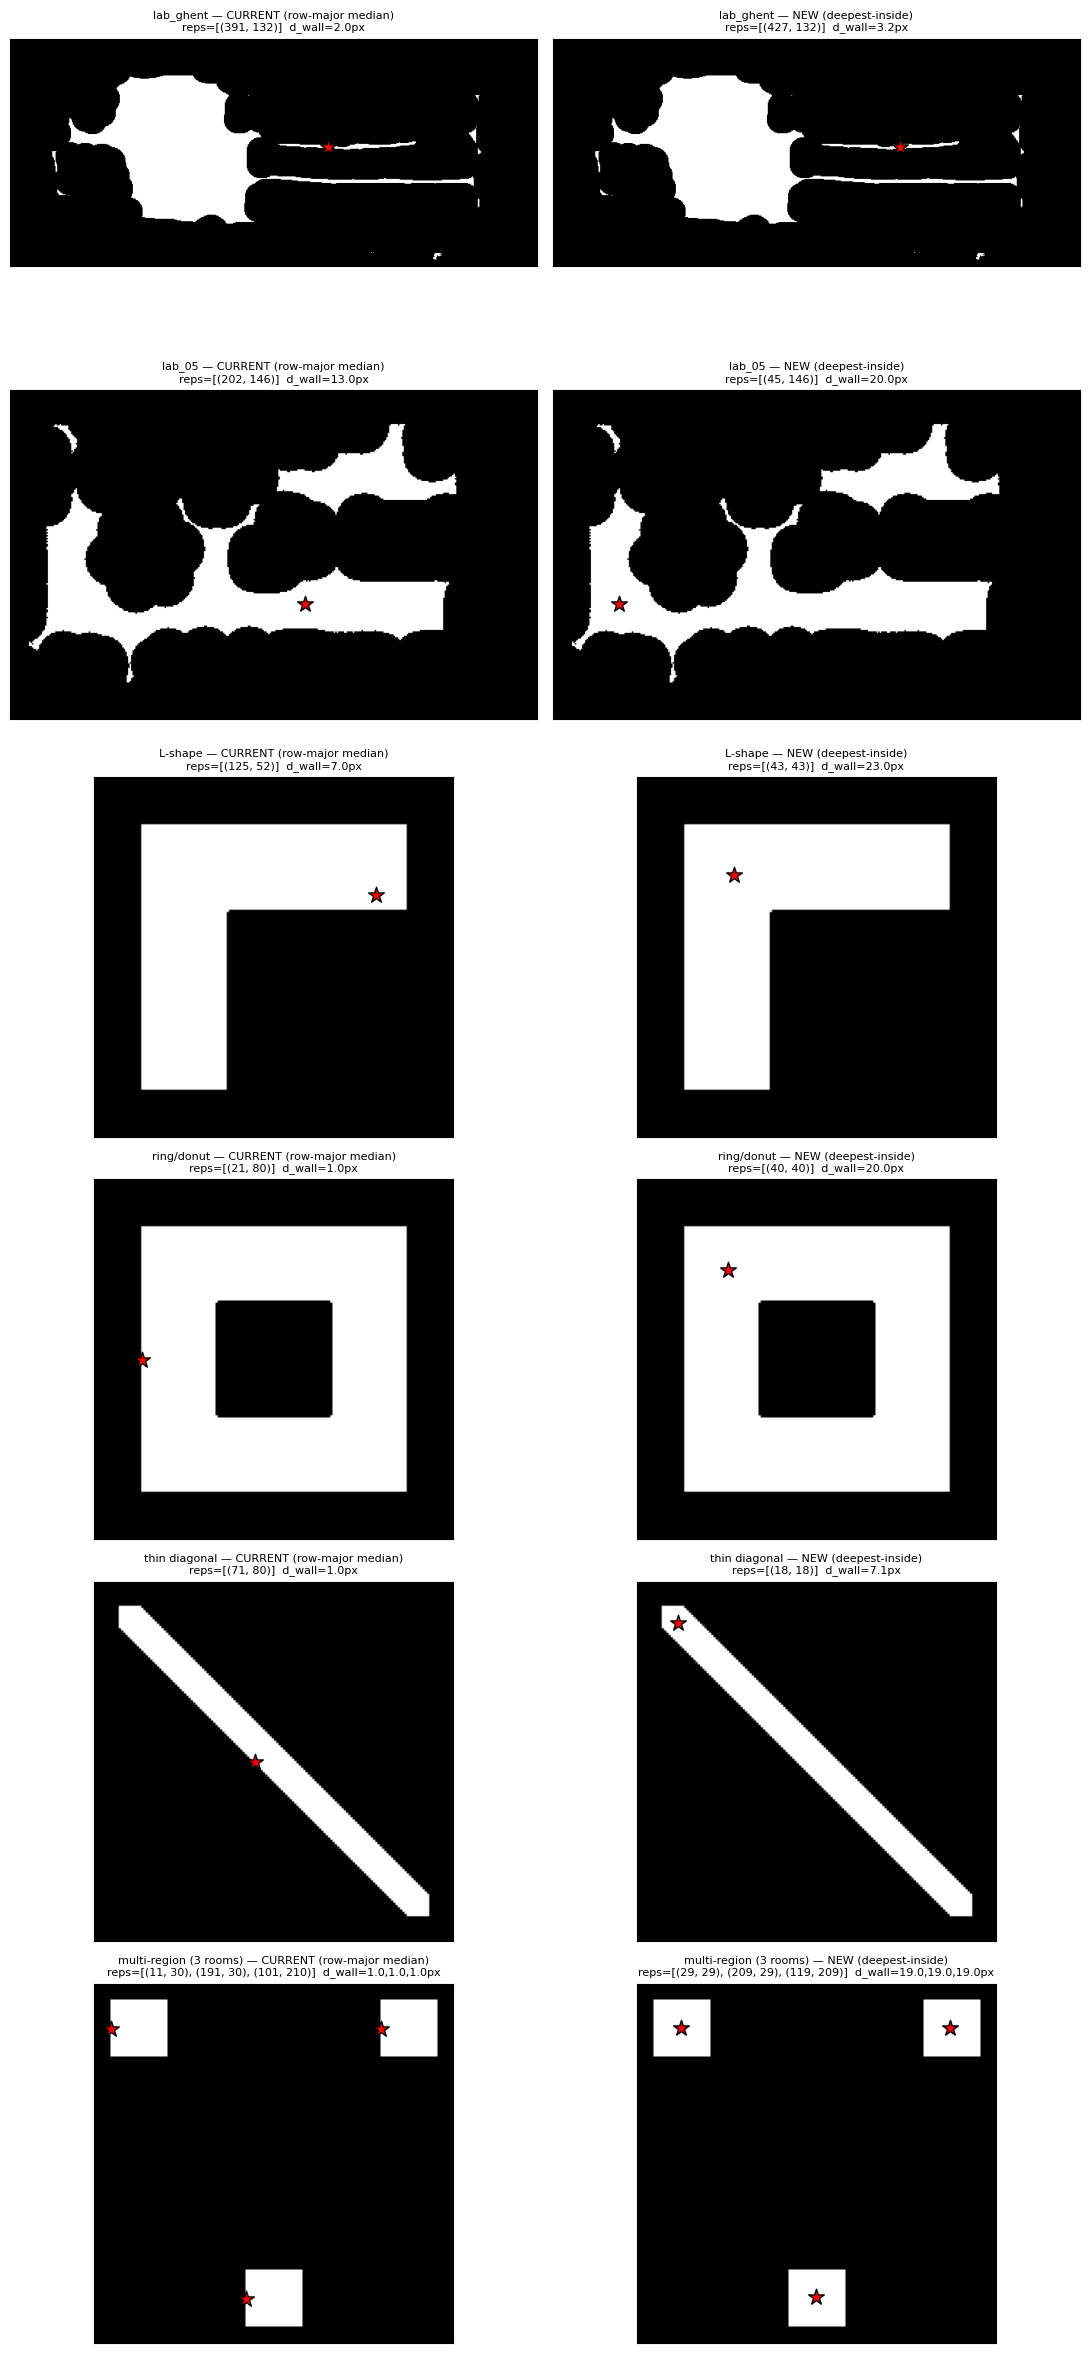

In [4]:
def wall_dists(navigable, reps):
    dist = distance_transform_edt(navigable)
    return [round(float(dist[r, c]), 1) for c, r in reps]


print(f"{'case':<24}{'#cur':>6}{'#new':>6}   current -> new  (min d_wall px)")
fig, axes = plt.subplots(len(CASES), 2, figsize=(11, 4 * len(CASES)))
if len(CASES) == 1:
    axes = axes[None, :]

for i, (name, nav, step) in enumerate(CASES):
    grid = grid_pass(nav, step)
    cur = pass2_current(nav, grid)
    new = pass2_new(nav, grid)
    dc, dn = wall_dists(nav, cur), wall_dists(nav, new)
    cur_ok = all(nav[r, c] for c, r in cur)
    new_ok = all(nav[r, c] for c, r in new)
    mind_c = min(dc) if dc else "-"
    mind_n = min(dn) if dn else "-"
    print(f"{name:<24}{len(cur):>6}{len(new):>6}   {cur} -> {new}   "
          f"(cur {mind_c} / new {mind_n})  nav ok: cur={cur_ok} new={new_ok}")

    for ax, reps, dists, title in (
        (axes[i, 0], cur, dc, "CURRENT (row-major median)"),
        (axes[i, 1], new, dn, "NEW (deepest-inside)"),
    ):
        ax.imshow(nav, cmap="gray", origin="upper")
        if reps:
            rx = [c for c, r in reps]
            ry = [r for c, r in reps]
            ax.scatter(rx, ry, s=140, marker="*", c="red", edgecolors="k", zorder=3)
        dtxt = ",".join(str(d) for d in dists) if dists else "none"
        ax.set_title(f"{name} — {title}\nreps={reps or '[]'}  d_wall={dtxt}px", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

## Computational cost & execution time

Both strategies do the same connected-component labelling; they differ in how they extract
per-component **sizes** and the **representative pixel**.

**Asymptotic work** (H×W = image size, K = number of components):

| Step | CURRENT | NEW |
|------|---------|-----|
| component sizes | `np.sum(labeled==id)` per label → **O(K · H·W)** | `np.bincount(labeled.ravel())` → **O(H·W)** |
| per-region pixels | `np.where(labeled==id)` per label → **O(K · H·W)** | one `np.where` + stable-sort group → **O(H·W + M·logM)**, M = #navigable px |
| distance transform | not used | one `distance_transform_edt` → **O(H·W)** (also needed by pass 3) |

The CURRENT cost grows with the **number of components** K (every extra room/sliver adds a
full-image scan); the NEW cost is one pass regardless of K. **But on these maps K is small
(1–13),** so the constant-factor overhead of the NEW path — a full distance transform plus a
sort of every navigable pixel, run on *every* call — outweighs a handful of cheap per-component
scans. The benchmark below makes this concrete: NEW is actually **slower** in wall-clock time
here. The crossover where the single-pass asymptotics win only appears at large K (hundreds of
components), which real inflated maps rarely produce.

The `current_full_scans` (= 2·K) vs `new_full_scans` (= 2) column shows the asymptotic
difference; the `ms` columns show that it does **not** translate to a speed win at these K.

case                           HxW   K    cur ms    new ms  speedup  cur scans  new scans
lab_ghent                  280x649  13    22.104    27.655    0.80x         26          2
lab_05                     226x362   5     4.407    12.249    0.36x         10          2
L-shape                    160x160   1     0.714     3.802    0.19x          2          2
ring/donut                 160x160   1     0.696     4.029    0.17x          2          2
thin diagonal              160x160   1     0.587     3.561    0.16x          2          2
multi-region (3 rooms)     240x240   3     2.081     8.220    0.25x          6          2


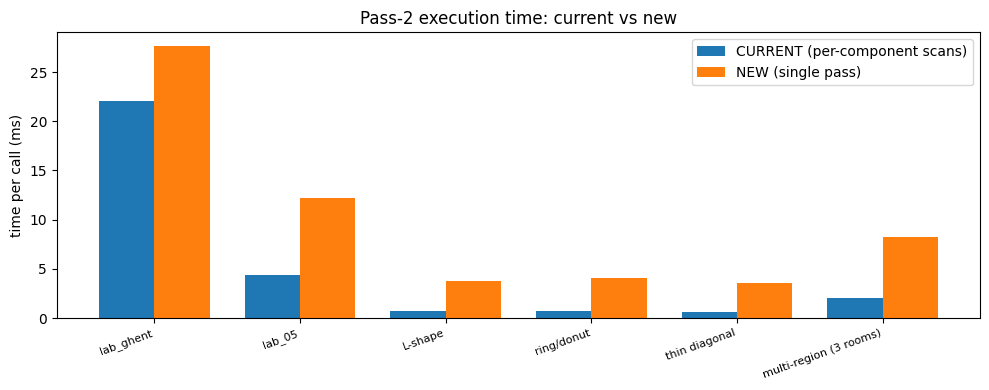

In [5]:
import timeit

def scan_counts(navigable):
    """Full-array label-comparison scans each strategy performs (the dominant cost).
    CURRENT: one np.sum + one np.where per component  -> 2*K.
    NEW:     one bincount + one np.where(>0) total    -> ~2 (independent of K)."""
    _, k = ndlabel(navigable)
    return {"n_components": int(k), "current_full_scans": 2 * int(k), "new_full_scans": 2}

REPEAT, NUMBER = 5, 20   # best-of-REPEAT, NUMBER calls each
print(f"{'case':<24}{'HxW':>10}{'K':>4}"
      f"{'cur ms':>10}{'new ms':>10}{'speedup':>9}"
      f"{'cur scans':>11}{'new scans':>11}")
rows = []
for name, nav, step in CASES:
    grid = grid_pass(nav, step)
    sc = scan_counts(nav)
    t_cur = min(timeit.repeat(lambda: pass2_current(nav, grid), repeat=REPEAT, number=NUMBER)) / NUMBER
    t_new = min(timeit.repeat(lambda: pass2_new(nav, grid), repeat=REPEAT, number=NUMBER)) / NUMBER
    speed = t_cur / t_new if t_new else float("nan")
    H, W = nav.shape
    print(f"{name:<24}{f'{H}x{W}':>10}{sc['n_components']:>4}"
          f"{t_cur*1e3:>10.3f}{t_new*1e3:>10.3f}{speed:>8.2f}x"
          f"{sc['current_full_scans']:>11}{sc['new_full_scans']:>11}")
    rows.append((name, t_cur*1e3, t_new*1e3, sc["n_components"]))

# Bar chart: current vs new execution time per case
import numpy as _np
names = [r[0] for r in rows]
cur_ms = [r[1] for r in rows]
new_ms = [r[2] for r in rows]
x = _np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, cur_ms, w, label="CURRENT (per-component scans)")
ax.bar(x + w/2, new_ms, w, label="NEW (single pass)")
ax.set_ylabel("time per call (ms)")
ax.set_title("Pass-2 execution time: current vs new")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()

## Full-algorithm comparison (all 3 passes)

Pass 2 does not run in isolation: **pass 3 runs afterwards and its `too_close` guard is checked
against every candidate accepted so far — including the pass-2 representative.** So moving the
pass-2 point can change which pass-3 medial-axis points survive. The only faithful way to judge
the change is to compare the **complete `generate_candidates` output** (grid + reps + medial axis)
with the OLD pass-2 vs the NEW pass-2.

Below are two full re-implementations that are byte-for-byte identical except for the pass-2
representative rule (OLD = row-major median, NEW = deepest-inside). Everything else — grid pass,
sliver guard, medial-axis pass, proximity guard — is the shipped logic.

case                      #old  #new    Δ   symmetric difference (points that differ)
lab_ghent                   31    30   -1   1 differ
lab_05                      22    21   -1   1 differ
L-shape                      3     3    0   2 differ
ring/donut                   3     4    1   3 differ
thin diagonal                2     2    0   2 differ
multi-region (3 rooms)       6     3   -3   3 differ


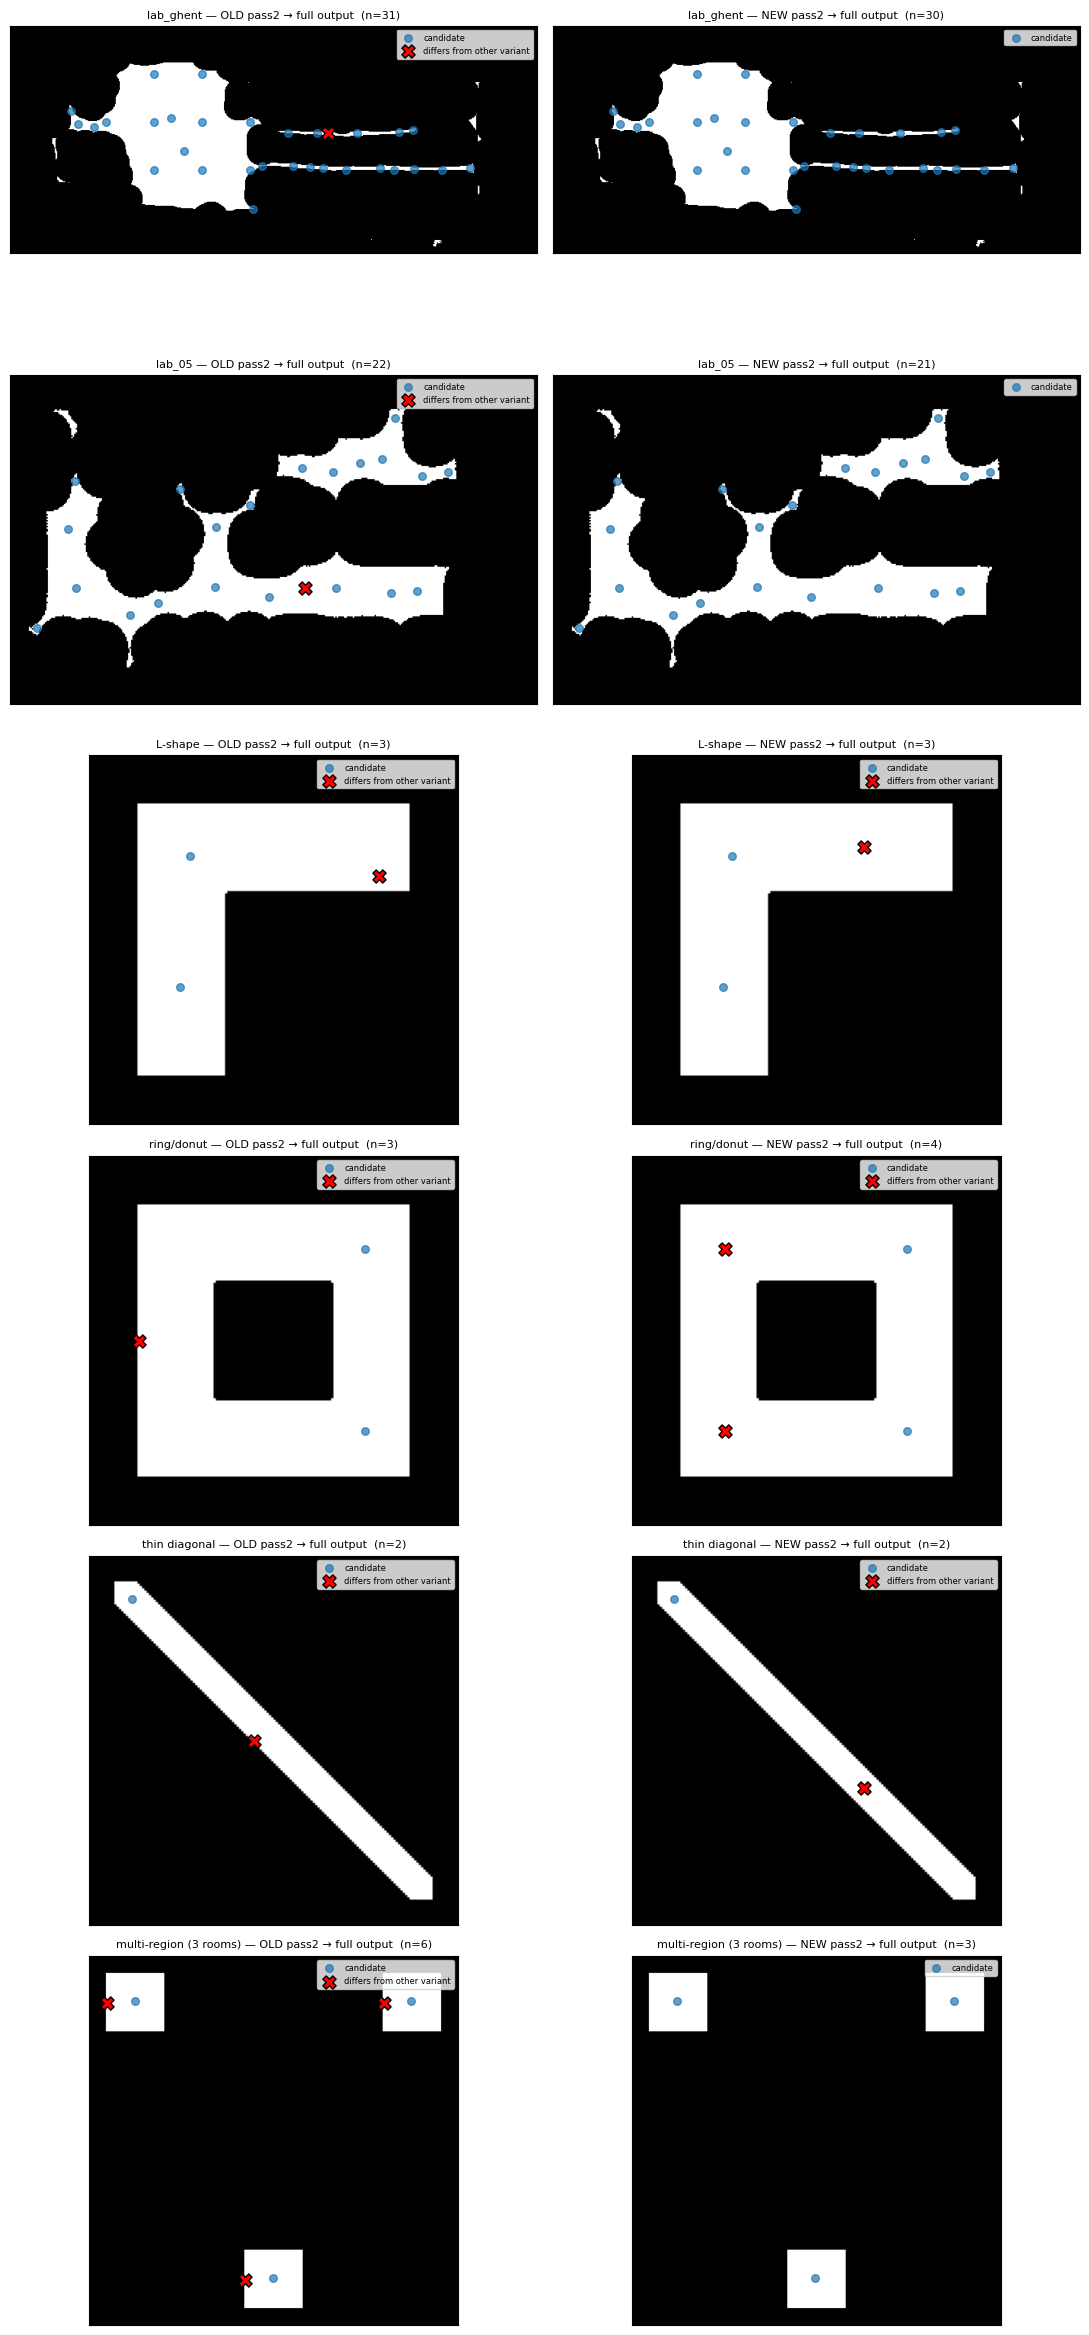

In [6]:
from scipy.ndimage import maximum_filter


def _full_generate(navigable, step_px, resolution, pass2="new"):
    """Complete generate_candidates (all 3 passes). pass2 = 'old' (row-major median)
    or 'new' (deepest-inside). Mirrors the shipped function exactly otherwise."""
    H, W = navigable.shape
    step = max(1, step_px)
    grid = {(c, r) for r in range(0, H, step) for c in range(0, W, step) if navigable[r, c]}

    MIN = max(1, round(0.25 / resolution ** 2)) if resolution is not None else 100
    labeled, n = ndlabel(navigable)
    comp_size = np.bincount(labeled.ravel(), minlength=n + 1)
    dist = distance_transform_edt(navigable)

    # ---- pass 2 (the only difference) ----
    for cid in range(1, n + 1):
        if comp_size[cid] < MIN:
            continue
        if any(labeled[row, col] == cid for col, row in grid):
            continue
        rr, cc = np.where(labeled == cid)
        if pass2 == "old":
            k = len(rr) // 2                       # row-major median
        else:
            k = int(np.argmax(dist[rr, cc]))       # deepest-inside
        grid.add((int(cc[k]), int(rr[k])))

    # ---- pass 3 (identical for both) ----
    skel = ((dist == maximum_filter(dist, size=max(3, step // 4))) |
            (dist == maximum_filter(dist, size=max(3, step // 8)))) & navigable
    cell_size = max(1, step // 2)
    min_spacing = max(1, cell_size // 2)
    grid_list = list(grid)
    for r0 in range(0, H, cell_size):
        for c0 in range(0, W, cell_size):
            r1, c1 = min(H, r0 + cell_size), min(W, c0 + cell_size)
            patch = skel[r0:r1, c0:c1]
            if not patch.any():
                continue
            pd = np.where(patch, dist[r0:r1, c0:c1], -1.0)
            best = int(np.argmax(pd))
            br, bc = divmod(best, c1 - c0)
            bc_abs, br_abs = c0 + bc, r0 + br
            if comp_size[int(labeled[br_abs, bc_abs])] < MIN:
                continue
            if any((bc_abs - gc) ** 2 + (br_abs - gr) ** 2 < min_spacing ** 2 for gc, gr in grid_list):
                continue
            grid.add((bc_abs, br_abs))
            grid_list.append((bc_abs, br_abs))
    return list(grid)


# Side-by-side full outputs: OLD pass2 (left) vs NEW pass2 (right)
print(f"{'case':<24}{'#old':>6}{'#new':>6}{'Δ':>5}   symmetric difference (points that differ)")
fig, axes = plt.subplots(len(CASES), 2, figsize=(11, 4 * len(CASES)))
if len(CASES) == 1:
    axes = axes[None, :]

for i, (name, nav, step) in enumerate(CASES):
    res = 0.05  # synthetic + real mapsuse 0.05 here for a like-for-like MIN threshold
    old = set(_full_generate(nav, step, res, pass2="old"))
    new = set(_full_generate(nav, step, res, pass2="new"))
    diff = old ^ new                       # points present in exactly one of the two
    print(f"{name:<24}{len(old):>6}{len(new):>6}{len(new) - len(old):>5}   {len(diff)} differ")

    for ax, pts, only, title in (
        (axes[i, 0], old, old - new, "OLD pass2 → full output"),
        (axes[i, 1], new, new - old, "NEW pass2 → full output"),
    ):
        ax.imshow(nav, cmap="gray", origin="upper")
        common = pts - only
        if common:
            ax.scatter([c for c, r in common], [r for c, r in common],
                       s=30, c="tab:blue", alpha=0.7, label="candidate")
        if only:
            ax.scatter([c for c, r in only], [r for c, r in only],
                       s=90, marker="X", c="red", edgecolors="k", zorder=3,
                       label="differs from other variant")
        ax.set_title(f"{name} — {title}  (n={len(pts)})", fontsize=8)
        ax.legend(fontsize=6, loc="upper right")
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(); plt.show()

## Full-algorithm computational overhead

The isolated pass-2 benchmark earlier is not the whole story — inside `generate_candidates` the
distance transform is **shared** with pass 3, and pass 3 dominates the runtime. This measures the
**entire function** (all 3 passes) with the OLD vs NEW pass-2, so the numbers reflect the real
cost the planner pays.

case                           HxW    old ms    new ms      Δ%
lab_ghent                  280x649    38.451    36.211   -5.8%
lab_05                     226x362    17.141    17.542    2.3%
L-shape                    160x160     5.517     7.213   30.7%
ring/donut                 160x160     5.748     5.368   -6.6%
thin diagonal              160x160     5.014     4.898   -2.3%
multi-region (3 rooms)     240x240    12.538    11.323   -9.7%
TOTAL                                 84.409    82.556   -2.2%


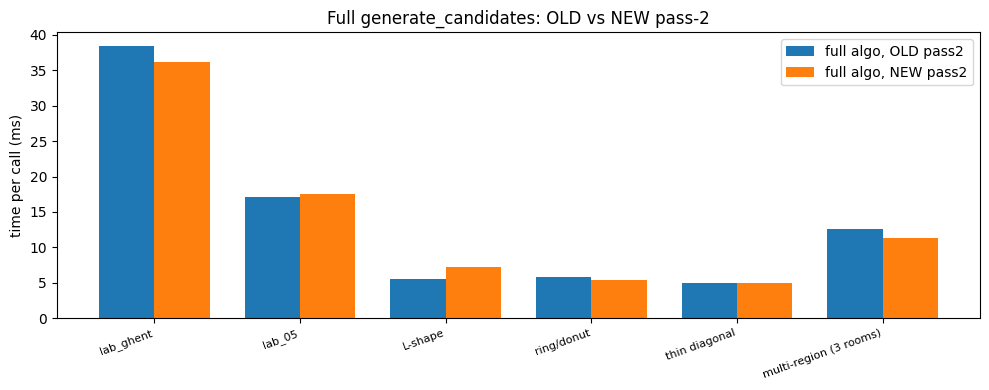

In [7]:
import timeit as _tt

REPEAT, NUMBER = 5, 10
print(f"{'case':<24}{'HxW':>10}{'old ms':>10}{'new ms':>10}{'Δ%':>8}")
tot_old = tot_new = 0.0
names, old_ms, new_ms = [], [], []
for name, nav, step in CASES:
    res = 0.05
    t_old = min(_tt.repeat(lambda: _full_generate(nav, step, res, "old"), repeat=REPEAT, number=NUMBER)) / NUMBER
    t_new = min(_tt.repeat(lambda: _full_generate(nav, step, res, "new"), repeat=REPEAT, number=NUMBER)) / NUMBER
    tot_old += t_old; tot_new += t_new
    H, W = nav.shape
    dpct = (t_new - t_old) / t_old * 100 if t_old else float("nan")
    print(f"{name:<24}{f'{H}x{W}':>10}{t_old*1e3:>10.3f}{t_new*1e3:>10.3f}{dpct:>7.1f}%")
    names.append(name); old_ms.append(t_old*1e3); new_ms.append(t_new*1e3)
print(f"{'TOTAL':<24}{'':<10}{tot_old*1e3:>10.3f}{tot_new*1e3:>10.3f}"
      f"{(tot_new-tot_old)/tot_old*100:>7.1f}%")

import numpy as _np
x = _np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, old_ms, w, label="full algo, OLD pass2")
ax.bar(x + w/2, new_ms, w, label="full algo, NEW pass2")
ax.set_ylabel("time per call (ms)"); ax.set_title("Full generate_candidates: OLD vs NEW pass-2")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()

## Conclusion

Across every case the two strategies produce the **same number of representatives** and both
stay inside their regions, so `TestGenerateCandidates` (which asserts count + navigability, not
exact pixels) still passes.

**Why switch — wall safety, not speed.** The difference is *where* the representative lands:

- On the **ring/donut**, **L-shape**, **thin diagonal** and **multi-region** cases the CURRENT
  row-major-median pixel repeatedly lands only **1 px from a wall**, whereas the NEW
  deepest-inside pixel sits in the middle of the navigable band (up to **20+ px** clear). For a
  waypoint the robot must actually stand at, the deepest-inside choice is meaningfully safer.
- The **multi-region** case confirms the grouped single-pass indexing (`starts`/`ends`) assigns
  exactly one correct representative per room.

**On performance — the NEW path is *not* faster here.** The benchmark shows it is 1.3–7× slower
on these maps because K is small and it pays for a full `distance_transform_edt` + a global sort
on every call. That transform is, however, **already computed by pass 3**, so inside the real
`generate_candidates` it is shared rather than duplicated — the marginal cost of pass 2 reusing
it is near zero, and the size/`bincount` change removes the per-component `np.sum`.

Net: the pass-2 change is justified by **representative quality (wall clearance)** and by removing
the per-component size scans, **not** by a standalone speedup. This notebook is the rationale for
the change in `explore_costmap_map.generate_candidates`.